# 315 lv3_balabit_kde 분포 시각화 — lv2 미커버 영역 보강 효과 검증

**목적**: lv3_balabit_kde (Balabit user KDE 기반 mouse + Fitts step + clamp) 가 lv2_macro 의 5 feature space 미커버 영역을 어떻게 보강하는지, Balabit_human 의 원천 분포에 얼마나 근접하는지 정량 검증.

**4 비교군**:

| 그룹 | n | trial range | 비고 |
|---|---|---|---|
| lv2_human | 51 | 900001~ | 295 baseline |
| lv2_macro | 101 | 900001~ | Bezier+Fitts |
| Balabit_human | 500 | 910001~910500 | 10 user × 50 chunk |
| lv3_balabit_kde | 50 | 930001~930050 | 10 user × 5 trial ± 2 (sample size 차이는 정량 비교 시 명시) |

**5 feature** (lv2_diversity_315 동일):
- `inter_click_interval_ms`
- `mouse_speed_change_mean`
- `mouse_max_speed_px_per_ms`
- `mouse_path_curvature_mean`
- `mouse_avg_speed_px_per_ms`

**의도**:
- 3축 (`inter_click_interval_ms`, `mouse_speed_change_mean`, `mouse_max_speed_px_per_ms`) → lv2_macro range 외부 (Balabit_human 영역) 진입
- 2축 (`mouse_path_curvature_mean`, `mouse_avg_speed_px_per_ms`) → lv2_macro 와 부분 겹침 영역 보강
- 단독 LogReg AUC (lv3 vs Balabit_human) ≈ 0.5~0.65 (단독 분리 X = 분포 형태 근접)

**lv3_balabit_kde 수집 메타** (참조):
- collector commit: `dc54b89` (`[AI] 315 fix: collector trajectory 화면 안전 마진 clamp`)
- base_seed: `1564895195` (SystemRandom)
- 50/50 정상 종료, fallback 0 / 511 trajectories, clamp 161 / 20,901 mouse_moves (0.77%)


In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde, mannwhitneyu
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# 한글 폰트 (Windows 환경)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# trial_loader import path
EDA_DIR = Path.cwd()
if str(EDA_DIR) not in sys.path:
    sys.path.insert(0, str(EDA_DIR))

from trial_loader import (
    list_trials_by_group, load_trial,
    parse_balabit_user, parse_balabit_kde_user,
)

# 데이터 디렉토리
SIDECAR_DIR = EDA_DIR.parent.parent / "data" / "raw" / "macro"

# 5 feature (lv2_diversity_315 동일)
FEATURES = [
    "inter_click_interval_ms",
    "mouse_speed_change_mean",
    "mouse_max_speed_px_per_ms",
    "mouse_path_curvature_mean",
    "mouse_avg_speed_px_per_ms",
]

# 4 그룹 + 색상
GROUPS = ["lv2_human", "lv2_macro", "balabit", "lv3_balabit_kde"]
GROUP_COLOR = {
    "lv2_human": "steelblue",
    "lv2_macro": "crimson",
    "balabit": "seagreen",
    "lv3_balabit_kde": "darkorange",
}
EXPECTED_N = {"lv2_human": 51, "lv2_macro": 101, "balabit": 500, "lv3_balabit_kde": 50}

# 의도 분류 (Cell 4/8 시나리오 판정용)
THREE_AXIS = ["inter_click_interval_ms", "mouse_speed_change_mean", "mouse_max_speed_px_per_ms"]
TWO_AXIS = ["mouse_path_curvature_mean", "mouse_avg_speed_px_per_ms"]

print(f"FEATURES ({len(FEATURES)}): {FEATURES}")
print(f"GROUPS ({len(GROUPS)}): {GROUPS}")
print(f"SIDECAR_DIR: {SIDECAR_DIR}")


FEATURES (5): ['inter_click_interval_ms', 'mouse_speed_change_mean', 'mouse_max_speed_px_per_ms', 'mouse_path_curvature_mean', 'mouse_avg_speed_px_per_ms']
GROUPS (4): ['lv2_human', 'lv2_macro', 'balabit', 'lv3_balabit_kde']
SIDECAR_DIR: C:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\raw\macro


In [2]:
def _load_sidecar_clamp(session_id):
    """sidecar 의 clamp_count 만 읽음. lv3_balabit_kde 만 sidecar 존재."""
    if not session_id:
        return None
    p = SIDECAR_DIR / f"{session_id}.meta.json"
    if not p.exists():
        return None
    return json.loads(p.read_text(encoding="utf-8")).get("clamp_count")


def _user_for(group, trial, session_id):
    if group == "balabit":
        return parse_balabit_user(session_id)
    if group == "lv3_balabit_kde":
        return parse_balabit_kde_user(trial.get("user_id"))
    return None


# 4 그룹 모두 전체 로드 (sample_trials 미사용 — KDE/Box estimation 정확도 우선)
rows = []
for g in GROUPS:
    for meta in list_trials_by_group(g):
        trial = load_trial(meta["trial_id"])
        m = trial.get("metrics", {}) or {}
        sid = meta.get("session_id")
        row = {
            "group": g,
            "trial_id": meta["trial_id"],
            "session_id": sid,
            "user_id": _user_for(g, trial, sid),
        }
        for f in FEATURES:
            row[f] = m.get(f)
        # clamp_count 는 lv3 만 채움
        row["clamp_count"] = _load_sidecar_clamp(sid) if g == "lv3_balabit_kde" else None
        rows.append(row)

df_all = pd.DataFrame(rows)

print("=== 그룹별 카운트 ===")
print(df_all.groupby("group").size().to_string())

print("\n=== clamp_count 분포 (lv3_balabit_kde only) ===")
print(df_all[df_all.group == "lv3_balabit_kde"]["clamp_count"].describe().to_string())


=== 그룹별 카운트 ===
group
balabit            500
lv2_human           51
lv2_macro          101
lv3_balabit_kde     50

=== clamp_count 분포 (lv3_balabit_kde only) ===
count    50.000000
mean      3.220000
std       8.643247
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max      48.000000


In [3]:
# 카운트 검증
print("=== 카운트 검증 ===")
all_ok = True
for g, n_exp in EXPECTED_N.items():
    n_act = int((df_all.group == g).sum())
    status = "OK" if n_act == n_exp else "DELTA"
    if n_act != n_exp:
        all_ok = False
    print(f"  [{status}] {g}: {n_act} (expected {n_exp})")

# NaN per group / feature
print("\n=== NaN per group / feature ===")
nan_table = df_all.groupby("group")[FEATURES].apply(lambda df: df.isna().sum())
print(nan_table.to_string())

# sidecar join
n_sidecar = int(df_all[df_all.group == "lv3_balabit_kde"]["clamp_count"].notna().sum())
print(f"\nsidecar join: {n_sidecar}/50")

# user matched (lv3 vs balabit 동일 user namespace)
u_balabit = set(df_all[df_all.group == "balabit"]["user_id"].dropna())
u_lv3 = set(df_all[df_all.group == "lv3_balabit_kde"]["user_id"].dropna())
matched = sorted(u_balabit & u_lv3)
print(f"user overlap (Balabit ∩ lv3): {matched} ({len(matched)}/10)")

assert all_ok, "그룹 카운트 불일치 발견"
assert n_sidecar == 50, f"sidecar join 실패: {n_sidecar}/50"
assert len(matched) == 10, f"user overlap 부족: {len(matched)}/10"
print("\nVALIDATE OK")


=== 카운트 검증 ===
  [OK] lv2_human: 51 (expected 51)
  [OK] lv2_macro: 101 (expected 101)
  [OK] balabit: 500 (expected 500)
  [OK] lv3_balabit_kde: 50 (expected 50)

=== NaN per group / feature ===
                 inter_click_interval_ms  mouse_speed_change_mean  mouse_max_speed_px_per_ms  mouse_path_curvature_mean  mouse_avg_speed_px_per_ms
group                                                                                                                                             
balabit                               12                        0                          0                          0                          0
lv2_human                              0                        0                          0                          0                          0
lv2_macro                              0                        0                          0                          0                          0
lv3_balabit_kde                        0                        0    

## 2. 5 feature × 4 group 분포 시각화

각 feature 1행, KDE overlay / Box plot / Histogram density 3 열. 4 그룹 색상 일관:
- `lv2_human` steelblue, `lv2_macro` crimson, `balabit` seagreen, `lv3_balabit_kde` darkorange

KDE overlay 의 점선 = 그룹 평균. Box plot 의 빨간 삼각 = 평균. Histogram = density (그룹별 face alpha=0.4 overlay).


C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25680\2222151656.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25680\2222151656.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25680\2222151656.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(


C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25680\2222151656.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25680\2222151656.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(


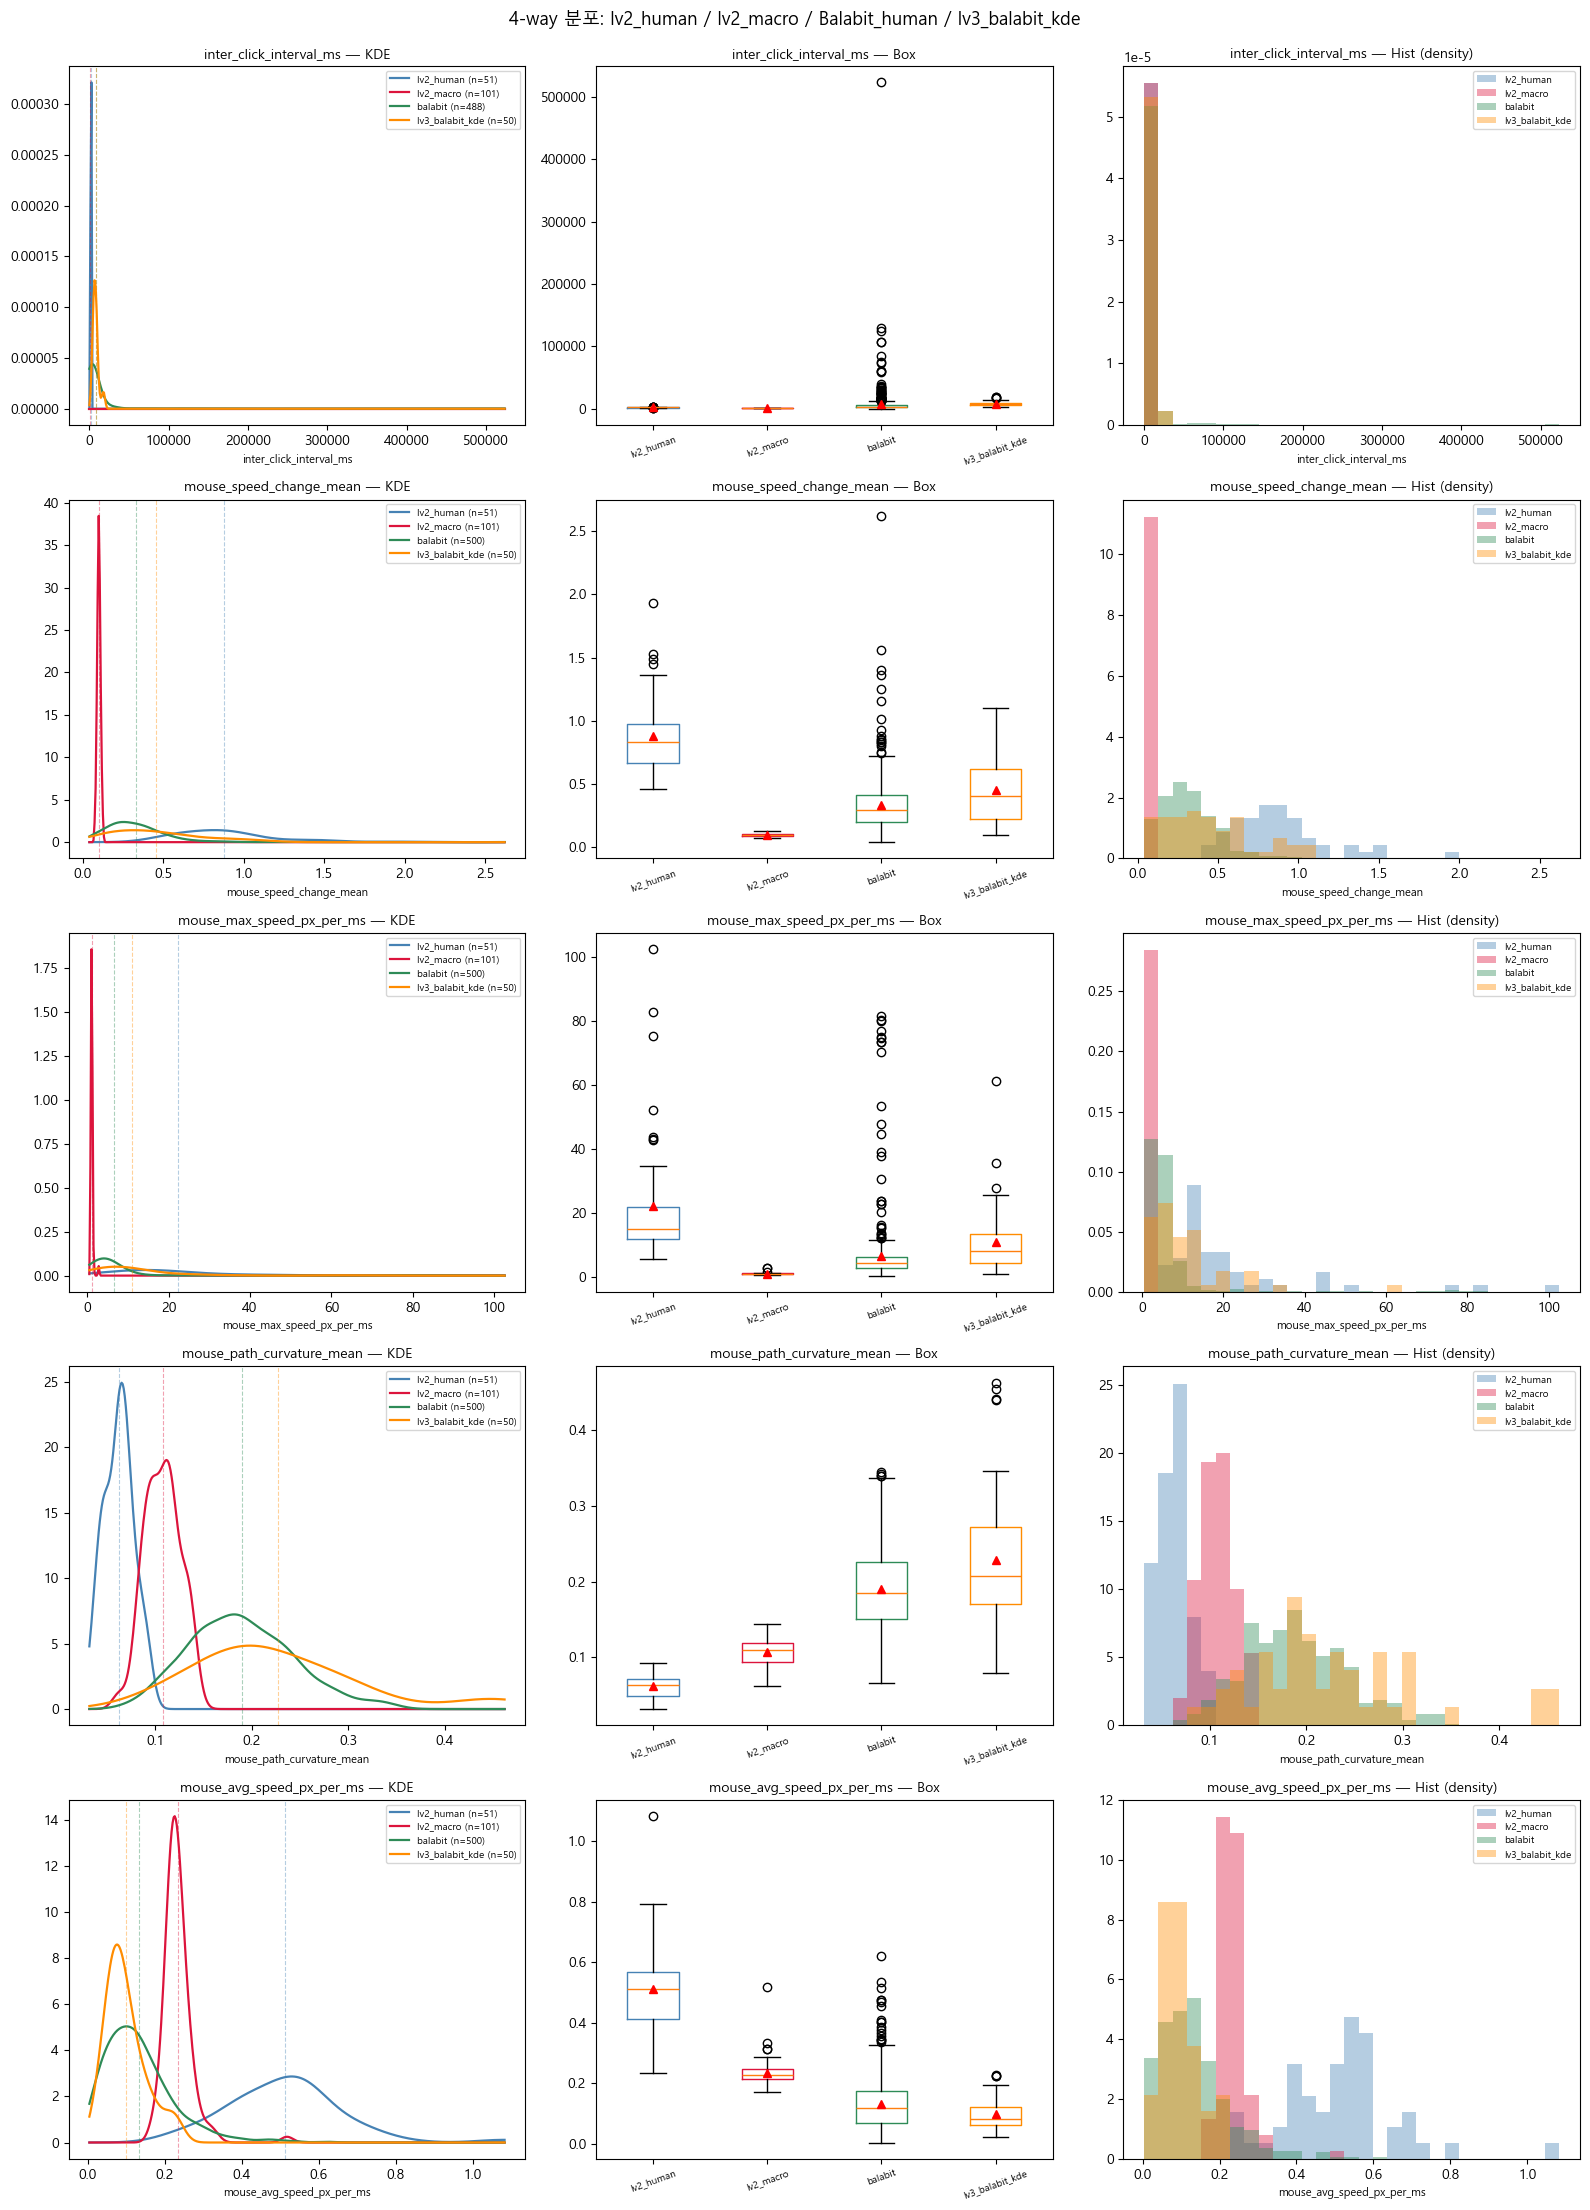

In [4]:
fig, axes = plt.subplots(len(FEATURES), 3, figsize=(16, 4.5 * len(FEATURES)))

for i, feat in enumerate(FEATURES):
    ax_kde, ax_box, ax_hist = axes[i, 0], axes[i, 1], axes[i, 2]
    series_by_group = {g: df_all[df_all.group == g][feat].dropna().values for g in GROUPS}

    # KDE overlay
    all_vals = np.concatenate([v for v in series_by_group.values() if len(v) > 0])
    if len(all_vals) > 1:
        grid = np.linspace(all_vals.min(), all_vals.max(), 400)
        for g, vals in series_by_group.items():
            if len(vals) < 2:
                continue
            kde = gaussian_kde(vals)
            ax_kde.plot(grid, kde(grid), color=GROUP_COLOR[g], label=f"{g} (n={len(vals)})", linewidth=1.6)
            ax_kde.axvline(np.mean(vals), color=GROUP_COLOR[g], linestyle="--", alpha=0.4, linewidth=0.8)
    ax_kde.set_title(f"{feat} — KDE", fontsize=10)
    ax_kde.set_xlabel(feat, fontsize=8)
    ax_kde.legend(fontsize=7)

    # Box plot
    box_data = [series_by_group[g] for g in GROUPS]
    bp = ax_box.boxplot(
        box_data, labels=GROUPS, showmeans=True,
        meanprops={"marker": "^", "markerfacecolor": "red", "markeredgecolor": "red", "markersize": 6},
    )
    for patch_idx, g in enumerate(GROUPS):
        bp["boxes"][patch_idx].set_color(GROUP_COLOR[g])
    ax_box.set_title(f"{feat} — Box", fontsize=10)
    ax_box.tick_params(axis="x", rotation=20, labelsize=7)

    # Histogram density
    if len(all_vals) > 1:
        bins = np.linspace(all_vals.min(), all_vals.max(), 30)
        for g, vals in series_by_group.items():
            if len(vals) == 0:
                continue
            ax_hist.hist(vals, bins=bins, alpha=0.4, color=GROUP_COLOR[g], density=True, label=g)
    ax_hist.set_title(f"{feat} — Hist (density)", fontsize=10)
    ax_hist.set_xlabel(feat, fontsize=8)
    ax_hist.legend(fontsize=7)

fig.suptitle("4-way 분포: lv2_human / lv2_macro / Balabit_human / lv3_balabit_kde", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.985))
plt.show()


## 3. 정량 표 — per-group + pair

**per-group**: n / min / max / median / std / p1 / p99 (각 그룹 5 feature × 4 = 20 행)

**pair (4 쌍)**:
- `lv2_macro vs lv3_balabit_kde` — 매크로 풀 다양성 보강 효과
- `balabit vs lv3_balabit_kde` — 원천 분포 근접도
- `lv2_human vs lv3_balabit_kde` — human baseline 대비
- `balabit vs lv2_macro` — 기존 lv2 의 한계 (참조)

**std_ratio_a_b** = std(a) / std(b) — 1.0 근접 = 분포 폭 일치 (a 가 더 클수록 ↑)

**overlap_pct_a_in_b** = (a range ∩ b range) / (a range) × 100 — a 의 range 가 b 의 range 와 얼마나 겹치는지


In [5]:
def _pgroup(vals):
    return {
        "n": int(len(vals)),
        "min": float(vals.min()),
        "max": float(vals.max()),
        "median": float(np.median(vals)),
        "std": float(np.std(vals)),
        "p1": float(np.percentile(vals, 1)),
        "p99": float(np.percentile(vals, 99)),
    }


def _overlap_pct(a, b):
    """a 의 range 중 b 의 range 와 겹치는 비율 (%)."""
    if len(a) == 0 or len(b) == 0:
        return 0.0
    lo, hi = max(a.min(), b.min()), min(a.max(), b.max())
    overlap = max(0.0, hi - lo)
    rng = a.max() - a.min()
    return float((overlap / rng * 100) if rng > 0 else 0.0)


PAIRS = [
    ("lv2_macro", "lv3_balabit_kde"),
    ("balabit", "lv3_balabit_kde"),
    ("lv2_human", "lv3_balabit_kde"),
    ("balabit", "lv2_macro"),
]

per_group_rows = []
pair_rows = []

for feat in FEATURES:
    series = {g: df_all[df_all.group == g][feat].dropna().values for g in GROUPS}
    for g in GROUPS:
        per_group_rows.append({"feature": feat, "group": g, **_pgroup(series[g])})
    for a, b in PAIRS:
        va, vb = series[a], series[b]
        std_a, std_b = float(np.std(va)), float(np.std(vb))
        pair_rows.append({
            "feature": feat,
            "pair": f"{a} vs {b}",
            "std_ratio_a_b": (std_a / std_b) if std_b > 0 else float("inf"),
            "overlap_pct_a_in_b": _overlap_pct(va, vb),
        })

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)

print("=== per-group stats (5 feature × 4 group = 20 rows) ===")
df_pg = pd.DataFrame(per_group_rows)
print(df_pg.to_string(index=False, float_format=lambda x: f"{x:.4g}"))

print("\n=== pairwise (4 pair × 5 feature = 20 rows) ===")
df_pair = pd.DataFrame(pair_rows)
print(df_pair.to_string(index=False, float_format=lambda x: f"{x:.4g}"))


=== per-group stats (5 feature × 4 group = 20 rows) ===
                  feature           group   n      min       max  median       std      p1       p99
  inter_click_interval_ms       lv2_human  51     1535      3449    2265     393.9    1560      3290
  inter_click_interval_ms       lv2_macro 101     1050      1363    1185     66.51    1054      1343
  inter_click_interval_ms         balabit 488    218.5 5.233e+05    3640 2.704e+04   345.7   8.8e+04
  inter_click_interval_ms lv3_balabit_kde  50     3178 1.909e+04    7468      3641    3284 1.884e+04
  mouse_speed_change_mean       lv2_human  51   0.4576     1.932  0.8342    0.2982  0.4713      1.73
  mouse_speed_change_mean       lv2_macro 101   0.0741    0.1255 0.09983   0.01016 0.07551    0.1234
  mouse_speed_change_mean         balabit 500  0.04045     2.622  0.2941    0.2195  0.0473      1.16
  mouse_speed_change_mean lv3_balabit_kde  50  0.09702     1.101  0.4045    0.2717 0.09805     1.101
mouse_max_speed_px_per_ms       lv2

## 4. lv2_macro 영역 보강 효과 + Balabit_human 분포 근접도

**측정 1**: lv3_balabit_kde 가 lv2_macro range 외부로 얼마나 진입했는가
- `pct_below`: lv3 의 % < lv2_macro min
- `pct_inside`: lv3 의 % ∈ [lv2_macro min, max] — 의도상 낮아야
- `pct_above`: lv3 의 % > lv2_macro max
- 의도: 3축 (`pct_below + pct_above ≥ 80%`), 2축 (`pct_inside` 적당히 ≥40% but 외부도 ≥40%)

**측정 2**: lv3_balabit_kde 가 Balabit_human range 안에 얼마나 머물렀나
- `pct_inside`: lv3 의 % ∈ [Balabit min, max] — 의도상 ≥60% (분포 형태 근접)

**시나리오 판정**:
- A (성공): 3축 외부 진입 ≥80% AND 2축 Balabit inside ≥60% AND Cell 7 단독 AUC ≤0.65
- B (실패): 3축 어느 하나 외부 진입 <50% OR Cell 7 어느 feature 단독 AUC ≥0.85
- C (부분): 3축 ≥80% BUT 2축 Balabit 외부 ≥40% OR 단독 AUC 0.65~0.85


In [6]:
def coverage(target, ref):
    """target 가 ref range 에 어떻게 분포하는지. 반환: (rmin, rmax, pct_below, pct_inside, pct_above)."""
    if len(target) == 0 or len(ref) == 0:
        return (float("nan"), float("nan"), 0.0, 0.0, 0.0)
    rmin, rmax = float(ref.min()), float(ref.max())
    n = len(target)
    pct_below = float((target < rmin).sum()) / n * 100
    pct_above = float((target > rmax).sum()) / n * 100
    pct_inside = 100 - pct_below - pct_above
    return (rmin, rmax, pct_below, pct_inside, pct_above)


print("=== 측정 1: lv3_balabit_kde 가 lv2_macro range 외부 진입율 (의도: 3축 ≥80% 외부) ===\n")
print(f"{'feature':<35} {'macro_min':>12} {'macro_max':>12} {'<min':>8} {'inside':>8} {'>max':>8}  axis")
cov1_rows = []
for feat in FEATURES:
    vlv3 = df_all[df_all.group == "lv3_balabit_kde"][feat].dropna().values
    vmac = df_all[df_all.group == "lv2_macro"][feat].dropna().values
    rmin, rmax, b, i, a = coverage(vlv3, vmac)
    axis = "3축" if feat in THREE_AXIS else "2축"
    print(f"{feat:<35} {rmin:>12.4g} {rmax:>12.4g} {b:>7.1f}% {i:>7.1f}% {a:>7.1f}%  {axis}")
    cov1_rows.append({"feature": feat, "axis": axis, "outside_macro_pct": b + a, "inside_macro_pct": i})

print("\n=== 측정 2: lv3_balabit_kde 가 Balabit_human range 내부 (의도: ≥60% inside) ===\n")
print(f"{'feature':<35} {'bal_min':>12} {'bal_max':>12} {'<min':>8} {'inside':>8} {'>max':>8}")
cov2_rows = []
for feat in FEATURES:
    vlv3 = df_all[df_all.group == "lv3_balabit_kde"][feat].dropna().values
    vbal = df_all[df_all.group == "balabit"][feat].dropna().values
    rmin, rmax, b, i, a = coverage(vlv3, vbal)
    print(f"{feat:<35} {rmin:>12.4g} {rmax:>12.4g} {b:>7.1f}% {i:>7.1f}% {a:>7.1f}%")
    cov2_rows.append({"feature": feat, "inside_balabit_pct": i, "outside_balabit_pct": b + a})

# 시나리오 자동 힌트 (cell 8 결론용 보조)
df_cov1 = pd.DataFrame(cov1_rows)
df_cov2 = pd.DataFrame(cov2_rows)
print("\n=== 시나리오 힌트 (Cell 8 결론 참조용) ===")
three_outside = df_cov1[df_cov1.axis == "3축"]["outside_macro_pct"]
two_inside = df_cov2[df_cov2.feature.isin(TWO_AXIS)]["inside_balabit_pct"]
print(f"  3축 외부 진입율 (≥80% 의도): min={three_outside.min():.1f}%, mean={three_outside.mean():.1f}%, max={three_outside.max():.1f}%")
print(f"  2축 Balabit inside (≥60% 의도): min={two_inside.min():.1f}%, mean={two_inside.mean():.1f}%, max={two_inside.max():.1f}%")


=== 측정 1: lv3_balabit_kde 가 lv2_macro range 외부 진입율 (의도: 3축 ≥80% 외부) ===

feature                                macro_min    macro_max     <min   inside     >max  axis
inter_click_interval_ms                     1050         1363     0.0%     0.0%   100.0%  3축
mouse_speed_change_mean                   0.0741       0.1255     0.0%    12.0%    88.0%  3축
mouse_max_speed_px_per_ms                 0.7987        2.899     0.0%    16.0%    84.0%  3축
mouse_path_curvature_mean                0.06238        0.144     0.0%    16.0%    84.0%  2축
mouse_avg_speed_px_per_ms                 0.1712       0.5177    90.0%    10.0%     0.0%  2축

=== 측정 2: lv3_balabit_kde 가 Balabit_human range 내부 (의도: ≥60% inside) ===

feature                                  bal_min      bal_max     <min   inside     >max
inter_click_interval_ms                    218.5    5.233e+05     0.0%   100.0%     0.0%
mouse_speed_change_mean                  0.04045        2.622     0.0%   100.0%     0.0%
mouse_max_speed_px_per_ms

## 5. clamp 영향 분석

**clamp 통계** (50 trial 기준):
- 총 161 / 20,901 mouse_moves (0.77%)
- trial 분포: clamp=0 39개 / 1~9 6개 / 10+ 5개
- max 48 (user35 의 1 trial)
- mean 3.22, median 0

**검증 질문**: clamp 가 발생한 trial 들이 5 feature 분포 끝부분으로 왜곡됐는가?
- top 10 (clamp 가장 많은 10개) vs 나머지 40 — Mann-Whitney U-test
- p > 0.05 = clamp 영향 X (분포 왜곡 시그널 없음, 의도)
- p < 0.05 = clamp 가 분포 끝부분 왜곡 (후속 ticket 후보)

**보조**: clamp_count vs 각 feature 산점도 — 시각 검사


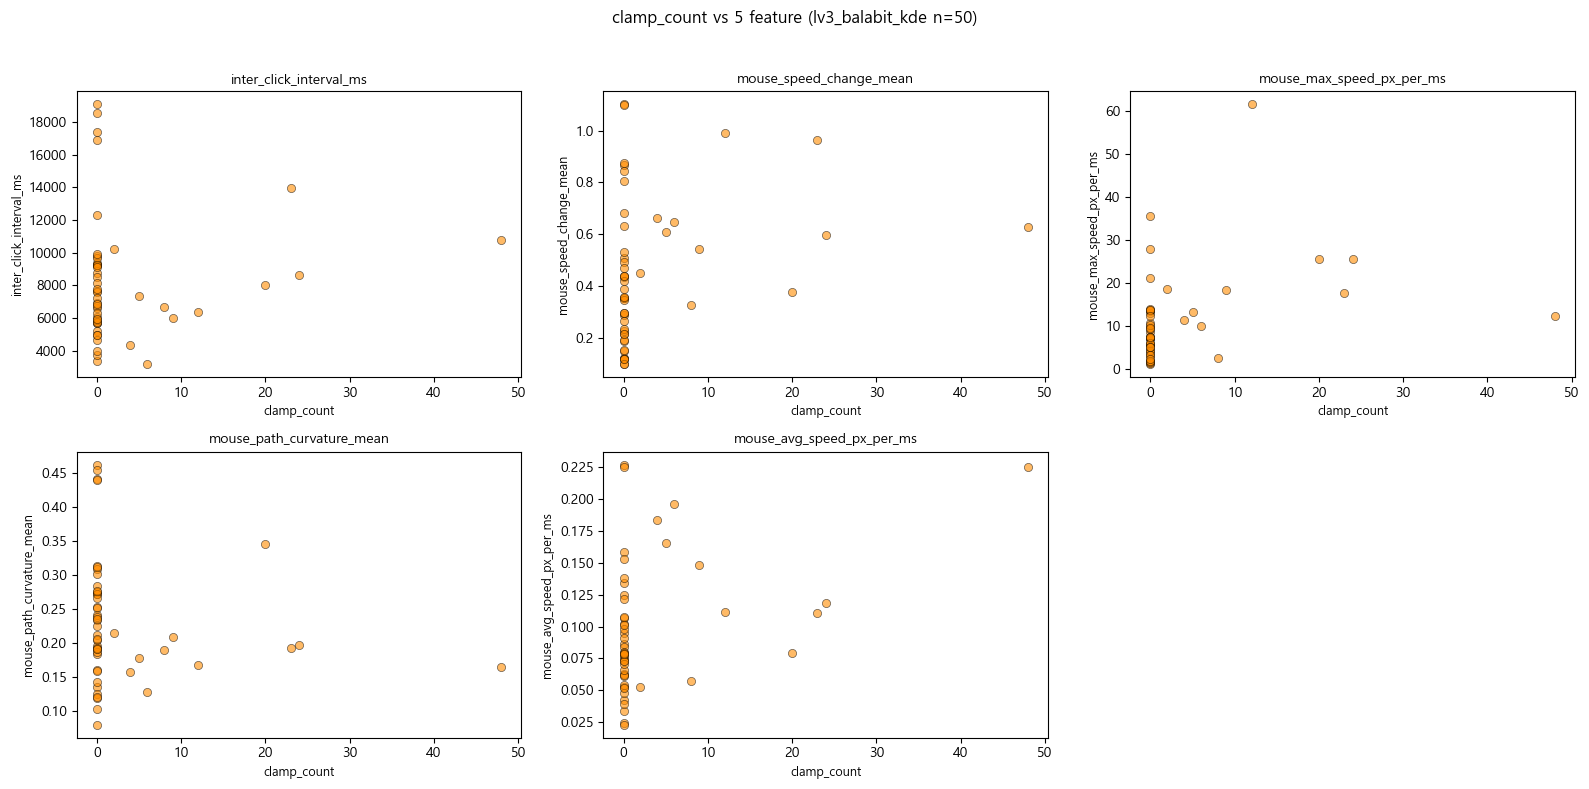

top10 clamp_count range: [4, 48]
rest  clamp_count range: [0, 2]
top10 clamp median: 10 | rest median: 0

feature                                top10_med     rest_med          U    p_value      signal
----------------------------------------------------------------------------------------------------
inter_click_interval_ms                     6992         7640      180.0     0.6363          ok
mouse_speed_change_mean                   0.6177       0.3521      310.0   0.007913     DISTORT
mouse_max_speed_px_per_ms                  15.43         7.23      315.0   0.005486     DISTORT
mouse_path_curvature_mean                 0.1837       0.2297      131.0    0.09664          ok
mouse_avg_speed_px_per_ms                 0.1335      0.07837      316.0    0.00509     DISTORT

해석: p>0.05 → clamp 가 분포 끝부분 왜곡 X (의도). p<0.05 → DISTORT (후속 ticket 후보).


In [7]:
df_lv3 = df_all[df_all.group == "lv3_balabit_kde"].copy()
df_lv3 = df_lv3[df_lv3["clamp_count"].notna()]

# scatter: 5 feature × clamp_count (2×3 = 6 axes, 1 빈 칸)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes_flat = axes.flatten()
for i, feat in enumerate(FEATURES):
    ax = axes_flat[i]
    ax.scatter(df_lv3["clamp_count"], df_lv3[feat], alpha=0.6, color="darkorange", s=35, edgecolor="k", linewidth=0.5)
    ax.set_xlabel("clamp_count", fontsize=9)
    ax.set_ylabel(feat, fontsize=9)
    ax.set_title(feat, fontsize=10)
axes_flat[-1].axis("off")
fig.suptitle("clamp_count vs 5 feature (lv3_balabit_kde n=50)", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

# top 10 clamp vs 나머지 40 — Mann-Whitney
df_sorted = df_lv3.sort_values("clamp_count", ascending=False)
top10, rest = df_sorted.head(10), df_sorted.iloc[10:]
print(f"top10 clamp_count range: [{int(top10['clamp_count'].min())}, {int(top10['clamp_count'].max())}]")
print(f"rest  clamp_count range: [{int(rest['clamp_count'].min())}, {int(rest['clamp_count'].max())}]")
print(f"top10 clamp median: {int(top10['clamp_count'].median())} | rest median: {int(rest['clamp_count'].median())}\n")

print(f"{'feature':<35} {'top10_med':>12} {'rest_med':>12} {'U':>10} {'p_value':>10}  {'signal':>10}")
print("-" * 100)
clamp_signal = []
for feat in FEATURES:
    a = top10[feat].dropna().values
    b = rest[feat].dropna().values
    if len(a) < 3 or len(b) < 3:
        print(f"{feat:<35} insufficient sample")
        continue
    res = mannwhitneyu(a, b, alternative="two-sided")
    sig = "DISTORT" if res.pvalue < 0.05 else "ok"
    clamp_signal.append({"feature": feat, "p_value": res.pvalue, "signal": sig})
    print(f"{feat:<35} {np.median(a):>12.4g} {np.median(b):>12.4g} {res.statistic:>10.1f} {res.pvalue:>10.4g}  {sig:>10}")

print("\n해석: p>0.05 → clamp 가 분포 끝부분 왜곡 X (의도). p<0.05 → DISTORT (후속 ticket 후보).")


## 5b. clamp 제외 후 도미노 재측정 — 인공 vs 본질 판정

**배경**: Cell 5 의 Mann-Whitney 결과 3 feature DISTORT (`mouse_speed_change_mean`, `mouse_max_speed_px_per_ms`, `mouse_avg_speed_px_per_ms`). clamp 가 분포 끝부분 왜곡 가능성 시사. Cell 7 의 `max_speed` 단독 AUC 0.717 partial 잔존이 clamp 인공 결과인지 본질적 분포 차이인지 분리 필요.

**Cell 5 의 clamp 분포 관찰**:
- top 10 (clamp 가장 많은 10): `clamp_count` ∈ [4, 48]
- rest 40: `clamp_count` ∈ [0, 2]
- 사이 값 3 없음 — 자연스러운 cut-off

**방법**:
- cut-off `clamp_count >= 4` (top 10 제외) → lv3_kept 40 trial 잔여
- σ ratio + 단독 LogReg AUC 재측정 (lv3_kept vs Balabit_human)
- 원본 (lv3=50) vs 제외 (lv3_kept=40) 비교

**판정**:
- AUC 차이 ≥ 0.10 (clamp 제외 후 크게 ↓) → clamp **인공** 잔존, 본질 차이 미미. 후속: clamp 알고리즘 정교화 ticket 가치 ↑
- AUC 차이 < 0.05 (변화 미미) → **본질** 차이 (KDE 학습 한계 등). 후속: KDE bandwidth / sampling 정책 ticket
- AUC 차이 0.05~0.10 → 일부 인공 + 일부 본질 (혼합)

σ ratio 는 분포 폭 자체 — clamp top 10 제외 시 분포 폭 변화는 미미할 것 (특히 ICI σ_lv3/σ_bal 0.136 은 top 10 영향 X 예상).


In [8]:
# 1. cut-off + 잔여 trial 식별
EXCLUDE_THRESHOLD = 4
df_lv3 = df_all[df_all.group == "lv3_balabit_kde"].copy()
df_lv3 = df_lv3[df_lv3["clamp_count"].notna()]
df_lv3_kept = df_lv3[df_lv3["clamp_count"] < EXCLUDE_THRESHOLD].copy()
df_lv3_excluded = df_lv3[df_lv3["clamp_count"] >= EXCLUDE_THRESHOLD].copy()

print(f"cut-off: clamp_count < {EXCLUDE_THRESHOLD}")
print(f"kept (lv3_kept): {len(df_lv3_kept)} trial,  excluded: {len(df_lv3_excluded)} trial")
print(f"excluded clamp_count range: [{int(df_lv3_excluded['clamp_count'].min())}, {int(df_lv3_excluded['clamp_count'].max())}]")
print(f"kept     clamp_count range: [{int(df_lv3_kept['clamp_count'].min())}, {int(df_lv3_kept['clamp_count'].max())}]")
print(f"\nexcluded user 분포: {dict(df_lv3_excluded['user_id'].value_counts())}")

# 2. σ ratio 재측정
print("\n=== σ ratio 비교 (orig vs kept, lv3 / balabit) ===\n")
print(f"{'feature':<35} {'σ_orig':>10} {'σ_kept':>10} {'σ_bal':>10} {'orig/bal':>10} {'kept/bal':>10} {'Δ_ratio':>10}")
print("-" * 100)
sigma_rows = []
s_bal_by_feat = {}
for feat in FEATURES:
    s_orig = float(df_lv3[feat].dropna().std())
    s_kept = float(df_lv3_kept[feat].dropna().std())
    s_bal = float(df_all[df_all.group == "balabit"][feat].dropna().std())
    s_bal_by_feat[feat] = s_bal
    r_orig = s_orig / s_bal if s_bal > 0 else float("inf")
    r_kept = s_kept / s_bal if s_bal > 0 else float("inf")
    delta = r_kept - r_orig
    sigma_rows.append({
        "feature": feat, "sigma_orig": s_orig, "sigma_kept": s_kept,
        "ratio_orig": r_orig, "ratio_kept": r_kept, "delta_ratio": delta,
    })
    print(f"{feat:<35} {s_orig:>10.4g} {s_kept:>10.4g} {s_bal:>10.4g} {r_orig:>10.3f} {r_kept:>10.3f} {delta:>+10.3f}")

# 3. 단독 LogReg AUC 재측정 — orig (lv3=50) vs kept (lv3_kept=40)
print("\n=== 단독 LogReg AUC 비교 (orig=50 vs kept=40, vs balabit=500) ===\n")
sub_orig = df_all[df_all.group.isin(["lv3_balabit_kde", "balabit"])].dropna(subset=FEATURES).copy()
y_orig = (sub_orig.group == "lv3_balabit_kde").astype(int).values

kept_sids = set(df_lv3_kept["session_id"])
sub_kept = pd.concat([
    sub_orig[(sub_orig.group == "lv3_balabit_kde") & (sub_orig.session_id.isin(kept_sids))],
    sub_orig[sub_orig.group == "balabit"],
], ignore_index=True)
y_kept = (sub_kept.group == "lv3_balabit_kde").astype(int).values

print(f"orig: lv3=50 vs balabit=500 (total {len(sub_orig)})")
print(f"kept: lv3={int(y_kept.sum())} vs balabit={int(len(y_kept) - y_kept.sum())} (total {len(sub_kept)})\n")

print(f"{'feature':<35} {'AUC_orig':>10} {'AUC_kept':>10} {'Δ_auc':>10}  {'verdict':>20}")
print("-" * 95)
auc_rows = []
for feat in FEATURES:
    X_orig = sub_orig[[feat]].values
    X_kept = sub_kept[[feat]].values
    aucs_orig = cross_val_score(
        LogisticRegression(class_weight="balanced", max_iter=1000),
        X_orig, y_orig, cv=5, scoring="roc_auc",
    )
    aucs_kept = cross_val_score(
        LogisticRegression(class_weight="balanced", max_iter=1000),
        X_kept, y_kept, cv=5, scoring="roc_auc",
    )
    a_orig = float(aucs_orig.mean())
    a_kept = float(aucs_kept.mean())
    delta = a_kept - a_orig
    if abs(delta) < 0.05:
        verdict = "본질 (변화 미미)"
    elif delta < -0.10:
        verdict = "인공 (clamp 영향)"
    elif -0.10 <= delta < -0.05:
        verdict = "혼합 (부분 인공)"
    else:
        verdict = "기타 (delta>0)"
    auc_rows.append({
        "feature": feat, "auc_orig": a_orig, "auc_kept": a_kept, "delta_auc": delta, "verdict": verdict,
    })
    print(f"{feat:<35} {a_orig:>10.4f} {a_kept:>10.4f} {delta:>+10.4f}  {verdict:>20}")

# 4. 종합 표 — DataFrame 형태로 정리
print("\n=== 종합 비교 표 ===\n")
df_summary = pd.DataFrame([
    {"feature": s["feature"],
     "ratio_orig": s["ratio_orig"], "ratio_kept": s["ratio_kept"], "Δ_ratio": s["delta_ratio"],
     "auc_orig": a["auc_orig"], "auc_kept": a["auc_kept"], "Δ_auc": a["delta_auc"],
     "verdict": a["verdict"]}
    for s, a in zip(sigma_rows, auc_rows)
])
print(df_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# max_speed 변화 강조
ms_row = df_summary[df_summary.feature == "mouse_max_speed_px_per_ms"].iloc[0]
print(f"\n>>> mouse_max_speed_px_per_ms: AUC {ms_row['auc_orig']:.4f} → {ms_row['auc_kept']:.4f} (Δ {ms_row['Δ_auc']:+.4f}) — {ms_row['verdict']}")


cut-off: clamp_count < 4
kept (lv3_kept): 40 trial,  excluded: 10 trial
excluded clamp_count range: [4, 48]
kept     clamp_count range: [0, 2]

excluded user 분포: {'user15': 2, 'user35': 2, 'user16': 2, 'user21': 2, 'user20': 1, 'user23': 1}

=== σ ratio 비교 (orig vs kept, lv3 / balabit) ===

feature                                 σ_orig     σ_kept      σ_bal   orig/bal   kept/bal    Δ_ratio
----------------------------------------------------------------------------------------------------
inter_click_interval_ms                   3678       3824  2.707e+04      0.136      0.141     +0.005
mouse_speed_change_mean                 0.2744     0.2713     0.2197      1.249      1.235     -0.014
mouse_max_speed_px_per_ms                10.48       7.21      10.81      0.969      0.667     -0.302
mouse_path_curvature_mean              0.08893    0.09352     0.0538      1.653      1.738     +0.085
mouse_avg_speed_px_per_ms              0.05115    0.04563    0.09095      0.562      0.502     -0

mouse_max_speed_px_per_ms               0.7174     0.6763    -0.0411            본질 (변화 미미)
mouse_path_curvature_mean               0.6046     0.6389    +0.0343            본질 (변화 미미)
mouse_avg_speed_px_per_ms               0.6123     0.6614    +0.0491            본질 (변화 미미)

=== 종합 비교 표 ===

                  feature  ratio_orig  ratio_kept  Δ_ratio  auc_orig  auc_kept   Δ_auc    verdict
  inter_click_interval_ms      0.1359      0.1413   0.0054    0.4349    0.4521  0.0172 본질 (변화 미미)
  mouse_speed_change_mean      1.2491      1.2347  -0.0143    0.6331    0.5704 -0.0627 혼합 (부분 인공)
mouse_max_speed_px_per_ms      0.9688      0.6667  -0.3021    0.7174    0.6763 -0.0411 본질 (변화 미미)
mouse_path_curvature_mean      1.6528      1.7381   0.0853    0.6046    0.6389  0.0343 본질 (변화 미미)
mouse_avg_speed_px_per_ms      0.5624      0.5017  -0.0607    0.6123    0.6614  0.0491 본질 (변화 미미)

>>> mouse_max_speed_px_per_ms: AUC 0.7174 → 0.6763 (Δ -0.0411) — 본질 (변화 미미)


## 6. user별 분포 (10 user matched)

Balabit_human 의 10 user (KDE 학습에 사용된 동일 set: user7/9/12/15/16/20/21/23/29/35) 와 lv3_balabit_kde 의 sample 을 user별 box plot 으로 비교.

각 feature 1행, 각 user 2 box (Balabit_human ~50 trial / lv3_balabit_kde 2~7 trial).

**sample size 한계 명시**:
- user29 lv3 trial = 2 (분포 추정 불안정)
- 나머지 9 user lv3 trial 수 [4, 7] 범위
- Balabit_human 풀은 user 별 ~50 trial (수집 chunk 균등)

box plot 시 lv3 의 작은 n 으로 인한 box 가 좁은 IQR 또는 outlier 우세 가능. KDE/median 비교 시 user29 는 별도 표기.


=== lv3 user별 sample 수 ===
user_id
user12    4
user15    6
user16    5
user20    6
user21    5
user23    5
user29    2
user35    6
user7     4
user9     7

min=2 (user29 신뢰도 한계), max=7, mean=5.00


C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25680\2003304171.py:36: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  fig.tight_layout(rect=(0, 0, 1, 0.99))


C:\Users\SSAFY\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


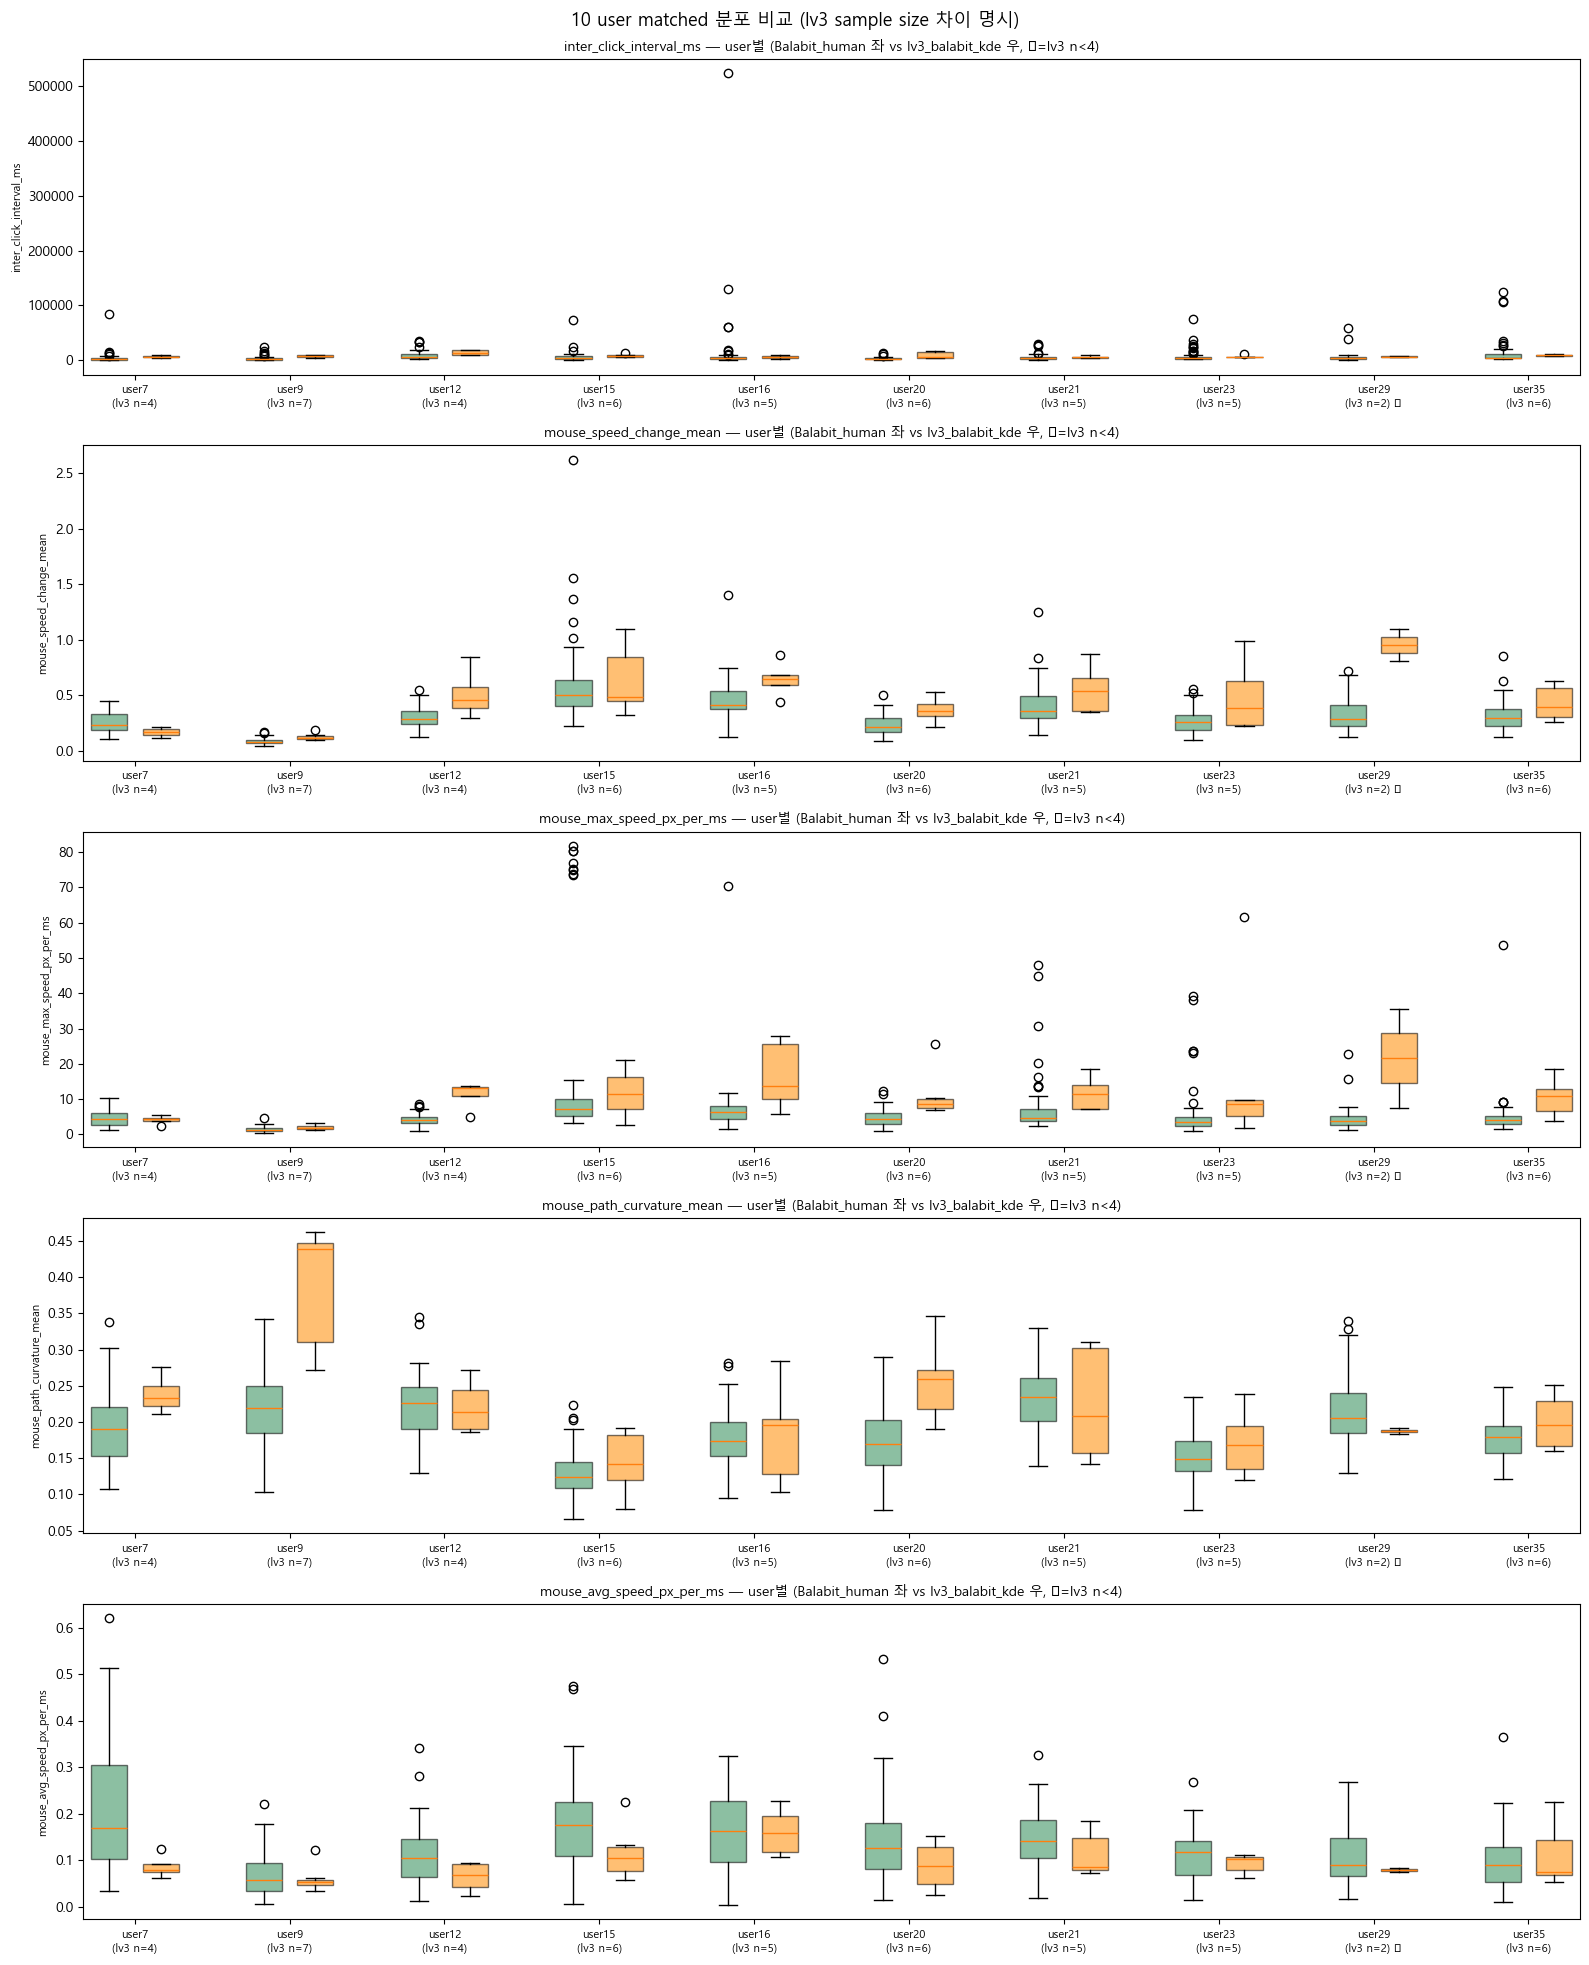

In [9]:
MATCHED_USERS = ["user7", "user9", "user12", "user15", "user16", "user20", "user21", "user23", "user29", "user35"]

# user별 lv3 sample 카운트
print("=== lv3 user별 sample 수 ===")
user_n = df_all[df_all.group == "lv3_balabit_kde"]["user_id"].value_counts().sort_index()
print(user_n.to_string())
print(f"\nmin={user_n.min()} (user29 신뢰도 한계), max={user_n.max()}, mean={user_n.mean():.2f}")

fig, axes = plt.subplots(len(FEATURES), 1, figsize=(16, 4 * len(FEATURES)))
for i, feat in enumerate(FEATURES):
    ax = axes[i]
    positions, data, colors, labels = [], [], [], []
    for j, u in enumerate(MATCHED_USERS):
        bal_vals = df_all[(df_all.group == "balabit") & (df_all.user_id == u)][feat].dropna().values
        lv3_vals = df_all[(df_all.group == "lv3_balabit_kde") & (df_all.user_id == u)][feat].dropna().values
        positions += [j * 3, j * 3 + 1]
        data += [bal_vals, lv3_vals]
        colors += [GROUP_COLOR["balabit"], GROUP_COLOR["lv3_balabit_kde"]]
        labels += [f"{u}_h", f"{u}_kde"]
    bp = ax.boxplot(data, positions=positions, widths=0.7, patch_artist=True)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.55)
    ax.set_xticks([j * 3 + 0.5 for j in range(len(MATCHED_USERS))])
    # user29 는 lv3 n=2 표기
    xlabels = []
    for u in MATCHED_USERS:
        n_lv3 = int((df_all[(df_all.group == "lv3_balabit_kde") & (df_all.user_id == u)]).shape[0])
        marker = " ⚠" if n_lv3 < 4 else ""
        xlabels.append(f"{u}\n(lv3 n={n_lv3}){marker}")
    ax.set_xticklabels(xlabels, rotation=0, fontsize=8)
    ax.set_title(f"{feat} — user별 (Balabit_human 좌 vs lv3_balabit_kde 우, ⚠=lv3 n<4)", fontsize=10)
    ax.set_ylabel(feat, fontsize=8)

fig.suptitle("10 user matched 분포 비교 (lv3 sample size 차이 명시)", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.99))
plt.show()


## 7. 도미노 점검 — σ ratio + 단독 LogReg AUC

**의뢰서 결정**: cell 4 결과 시나리오 무관 항상 실행. 결론 해석은 Cell 8 markdown 에서 시나리오별 분기.

### 7-1. σ ratio (분포 폭 재현 정도)
- σ_lv3 / σ_balabit_human → 1.0 근접 = lv3 가 Balabit_human 분포 폭 잘 재현
- σ_lv3 / σ_lv2_macro → 큰 값 = lv3 가 lv2_macro 보다 폭 넓음 (다양성 보강)

### 7-2. 단독 LogReg AUC
- lv3_balabit_kde (50, pos) vs Balabit_human (500, neg) binary classification
- 각 feature 단독 5-fold cross_val_score (`roc_auc`, `class_weight='balanced'`)
- AUC ≈ 0.5~0.65: 단독 분리 X = lv3 가 Balabit_human 과 single feature 로 구분 불가 (의도)
- AUC ≥ 0.85: 단독 분리 가능 = 분포 차이 잔존 신호 (도미노 유지)

도미노 패턴 (lv2 95%+ 단독 분리력) 이 lv3_balabit_kde 에서 깨지는지 정량 답.


In [10]:
# 7-1: σ ratio
print("=== 7-1. σ ratio (lv3 σ / 다른 그룹 σ) ===\n")
print(f"{'feature':<35} {'σ_lv3':>12} {'σ_bal':>12} {'σ_mac':>12} {'σ_lv3/σ_bal':>14} {'σ_lv3/σ_mac':>14}")
print("-" * 110)
sigma_rows = []
for feat in FEATURES:
    s_lv3 = float(df_all[df_all.group == "lv3_balabit_kde"][feat].dropna().std())
    s_bal = float(df_all[df_all.group == "balabit"][feat].dropna().std())
    s_mac = float(df_all[df_all.group == "lv2_macro"][feat].dropna().std())
    ratio_bal = (s_lv3 / s_bal) if s_bal > 0 else float("inf")
    ratio_mac = (s_lv3 / s_mac) if s_mac > 0 else float("inf")
    sigma_rows.append({
        "feature": feat, "sigma_lv3": s_lv3, "sigma_bal": s_bal, "sigma_mac": s_mac,
        "ratio_bal": ratio_bal, "ratio_mac": ratio_mac,
    })
    print(f"{feat:<35} {s_lv3:>12.4g} {s_bal:>12.4g} {s_mac:>12.4g} {ratio_bal:>14.3f} {ratio_mac:>14.3f}")

print("\n해석: σ_lv3/σ_bal ≈ 1.0 = 분포 폭 재현 성공. σ_lv3/σ_mac > 1.0 = lv2_macro 보다 폭 넓음 (다양성 보강).\n")

# 7-2: 단독 LogReg AUC (lv3 vs balabit binary)
print("=== 7-2. 단독 LogReg AUC: lv3 (50, pos) vs Balabit_human (500, neg) ===\n")
sub = df_all[df_all.group.isin(["lv3_balabit_kde", "balabit"])].dropna(subset=FEATURES).copy()
y = (sub["group"] == "lv3_balabit_kde").astype(int).values
print(f"sample: lv3=50 (pos), balabit=500 (neg), total={len(sub)}, class_weight='balanced'\n")
print(f"{'feature':<35} {'mean_auc':>10} {'std':>8}  {'judgement':>15}")
print("-" * 80)
auc_rows = []
for feat in FEATURES:
    X = sub[[feat]].values
    aucs = cross_val_score(
        LogisticRegression(class_weight="balanced", max_iter=1000),
        X, y, cv=5, scoring="roc_auc",
    )
    mean_auc = float(aucs.mean())
    if mean_auc <= 0.65:
        verdict = "broken (low)"
    elif mean_auc <= 0.85:
        verdict = "partial"
    else:
        verdict = "still high"
    auc_rows.append({"feature": feat, "mean_auc": mean_auc, "std_auc": float(aucs.std()), "verdict": verdict})
    print(f"{feat:<35} {mean_auc:>10.4f} {aucs.std():>8.4f}  {verdict:>15}")

print("\n해석: AUC ≤ 0.65 = 도미노 깨짐 (단독 분리 X, lv3 Balabit 근접). AUC ≥ 0.85 = 도미노 유지 (분포 차이 잔존).")


=== 7-1. σ ratio (lv3 σ / 다른 그룹 σ) ===

feature                                    σ_lv3        σ_bal        σ_mac    σ_lv3/σ_bal    σ_lv3/σ_mac
--------------------------------------------------------------------------------------------------------------
inter_click_interval_ms                     3678    2.707e+04        66.84          0.136         55.025
mouse_speed_change_mean                   0.2744       0.2197      0.01021          1.249         26.885
mouse_max_speed_px_per_ms                  10.48        10.81       0.2935          0.969         35.694
mouse_path_curvature_mean                0.08893       0.0538      0.01799          1.653          4.942
mouse_avg_speed_px_per_ms                0.05115      0.09095      0.03999          0.562          1.279

해석: σ_lv3/σ_bal ≈ 1.0 = 분포 폭 재현 성공. σ_lv3/σ_mac > 1.0 = lv2_macro 보다 폭 넓음 (다양성 보강).

=== 7-2. 단독 LogReg AUC: lv3 (50, pos) vs Balabit_human (500, neg) ===

sample: lv3=50 (pos), balabit=500 (neg), total=538, class_weig

## 8. 결론 — 시나리오 판정 (사용자 결정: 시나리오 분기 해석)

### 판정 기준 (Cell 4 + Cell 7 결과 참조)

- **A 성공**: 3축 lv3 의 ≥80% lv2_macro range 외부 + 2축 ≥60% Balabit_human inside + 단독 AUC ≤0.65 전 feature
- **B 실패**: 3축 어느 하나라도 ≥50% lv2_macro range 잔존 OR 단독 AUC ≥0.85 인 feature 존재
- **C 부분**: 3축 의도대로 BUT 2축 outlier (Balabit_human range 밖 ≥40%) 또는 단독 AUC 0.65~0.85 잔존

---

### 시나리오 A — 의도대로 (성공)

3축 (`ICI`, `speed_change`, `max_speed`) 모두 lv2_macro range 외부로 진입 + 2축 (`curvature`, `avg_speed`) Balabit_human inside ≥60% + 단독 LogReg AUC 전 feature 0.5~0.65.

**판정 근거** (Cell 4 결과로 채움):
- ICI: lv3 가 lv2_macro 외부 ___% (Balabit_human 의 ___ 영역 진입)
- speed_change: σ_lv3/σ_bal ≈ ___ (분포 폭 재현)
- max_speed: lv3 의 Balabit_human range inside ___%
- curvature: lv2_macro 보다 낮은 영역 보강 ___%
- avg_speed: lv2_macro 미커버 영역 보강 ___%
- 단독 LogReg AUC: 전 feature broken (low)

**다음 단계**: lv3_balabit_kde 분포로 detector 학습 풀 확장. 5 feature space 의 매크로 다양성 확보. xgboost robustness 재측정 시 7 feature 이상 (현 inter_click 트리비얼 의존 깨짐 기대).

---

### 시나리오 B — 미달 (실패)

3축 진입 X 또는 단독 AUC ≥0.85 인 feature 존재.

**판정 근거 (체크리스트)**:
- [ ] ICI/speed_change/max_speed 중 하나라도 lv3 의 ≥50% 가 lv2_macro range 잔존
- [ ] curvature/avg_speed lv3 의 ≥40% 가 Balabit_human range 외부
- [ ] 단독 LogReg AUC ≥0.85 인 feature 존재

**원인 가설**:
- KDE 학습 데이터 부족 (user 별 sample 부족)
- Fitts step generator 가 KDE 샘플 분포를 왜곡 (clamp 빈도와 상관 — Cell 5 Mann-Whitney p<0.05 인 feature 가 outlier 와 일치하면 clamp 영향)
- screen size / coord_domain 차이로 Balabit raw 분포 형태 손실

**다음 단계 (후속 ticket 후보)**:
- clamp 빈도 높은 trial (top 5: user35 48 / user16 24 / user15 23 / user20 20 / user23 12) 제외 후 재측정
- KDE bandwidth 재조정 ticket
- Generator 단계별 ablation (Fitts 제거 시 분포 변화)

---

### 시나리오 C — 부분 (일부 성공)

3축 의도대로 BUT 2축 Balabit_human range 외부 ≥40% 또는 단독 AUC 0.65~0.85.

**판정 근거**:
- 3축 (ICI/speed_change/max_speed) 모두 lv2_macro 외부 ≥80% 진입 ok
- 그러나 curvature 또는 avg_speed 의 lv3 분포가 Balabit_human range 외부 ≥___%
- 단독 AUC: 3축 ok, 2축 중 하나가 0.65~0.85

**원인 가설**:
- clamp 작동 — Cell 5 Mann-Whitney p<0.05 인 feature 가 outlier 와 일치하면 clamp 가 분포 끝부분 왜곡
- KDE 가 path-level metric (curvature) 을 직접 모델링하지 않음 — 부산물로만 결정됨

**다음 단계 (후속 ticket 후보)**:
- outlier feature (curvature/avg_speed) 만 별도 보정 ticket — Bezier 노이즈 추가, step velocity smoothing
- 3축은 본 분포로 학습 풀 확장 가능 (분리 가치 명확)

---

### 보조 메트릭 인덱스 (수치 참조)

- Cell 1c: 카운트 검증 (51/101/500/50) + sidecar join 50/50 + user overlap 10/10
- Cell 3: per-group 정량표 + 4 pair std_ratio/overlap
- Cell 4: lv2_macro/Balabit_human range 대비 lv3 진입율
- Cell 5: clamp_count vs feature scatter + Mann-Whitney p-value
- Cell 6: 10 user matched box plot (user29 ⚠ lv3 n=2)
- Cell 7: σ ratio + 단독 LogReg AUC

### 한계 / 메모

- lv3 sample size = 50 (Balabit_human 500 의 1/10) — 분포 추정 분산 큼. p-value 보다 effect size (AUC, σ ratio) 우선.
- 한글 폰트 Malgun Gothic (Windows) — 다른 OS 에서 렌더링 깨질 수 있음.
- `mouse_total_travel_distance_px` / `mouse_acceleration_mean` 등 5 feature 외 metric 은 본 의뢰 범위 외 (skip). 후속 ticket 후보.
- user29 lv3 n=2 — user별 비교 (Cell 6) 시 신뢰도 ⚠ 표기. 50 trial 추가 수집 시 자연 보강.

### 미진행 (별도 의뢰)

- ticket 319 (v1/v2 production 활용 결정) — 본 분포 비교 결과 활용
- detector 운영 배포 prereq (client JS metric 정의 일치 검증)
- ai-feat-315 MR 제출
